In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
from astropy import units as u
from astropy.time import Time
from astropy.coordinates import SkyCoord, EarthLocation, AltAz
from astropy.coordinates import get_sun

import matplotlib.colors as colors
import matplotlib.cm as cmx

%matplotlib inline

In [2]:
#download the latest IERS predictions by running:
from astropy.utils.data import download_file
from astropy.utils import iers
iers.IERS.iers_table = iers.IERS_A.open(download_file(iers.IERS_A_URL, cache=True))

# Field Rotation Calculation 
### Melso 2015 (updated 2019). Adapted from CNES GuideNavControl Document

In [3]:
class Field: 
    ''' 
    A class for storing and calculating information about each field location. 
    
    parameters
    ----------
    name (string): name of launch location
    date (string): observation date in format 'YYYY-MM-DD'
    dst (boolean): True if we are in daylight savings time (March 10 - Nov 3)
    '''
    
    def __init__(self, name, date, dst = False):
        
        self.name = name 
        self.date = date
        self.latlon = {'palestine': [33.0846, -95.8066], 
                       'ft_sumner': [34.4717, -104.2455]}
        
        
        self.utcoffset = {'palestine': 6.0*u.hour, 
                          'ft_sumner': 7.0*u.hour}
        if (dst == True): 
            self.utcoffset = {'palestine': 5.0*u.hour, 
                              'ft_sumner:': 6.0*u.hour}
            
    def location(self): 
        ''' 
        Set latitude and longitude. 

        returns 
        -------
        loc (object): astropy location object 
        '''
        coo = self.latlon[self.name]
        loc = EarthLocation(lat = coo[0]*u.deg, lon = coo[1]*u.deg, height = 40000.0*u.m)
        return loc 

    def set_datetime(self): 
        ''' 
        Set date/time and based on utc offset  

        returns 
        -------
        midnight (array): 
        delta_midnight (array): 
        '''
    
        midnight = Time(self.date + ' 00:00:00') + self.utcoffset[self.name]
        delta_midnight = np.linspace(-12, 12, 100000)*u.hour
    
        return midnight, delta_midnight
    
    def calc(self, obj, loc, midnight, delta_midnight):
        ''' 
        Calculate altitude, azimuth, and rotation speed for target
        
        parameters
        ----------
        obj (Astropy SkyCord object): e.g. SkyCoord(ra = [260.0, 37.0]*u.deg, dec = [60.0, 1.0]*u.deg)
        loc: location from function 
        midnight, delta_midnight: from set_datetime 
        '''
        rad = np.pi/180.
        
        # - altitutde and azimuth -#
        altaz = obj.transform_to(AltAz(obstime=midnight+delta_midnight, location = loc))
        alt = np.array((altaz.alt)*u.deg)
        az = np.array((altaz.az)*u.deg)

        # rotation speed
        rot_speed = (15.0417827*np.cos(self.latlon[self.name][0]*rad)*np.cos(az*rad))/np.cos(alt*rad)

        # - return label array -
        label = np.array(obj.dec*u.deg)
        
        return alt, az, rot_speed, label
    
    def integrate(self, alt, rs, hour, num): 
        ''' Calculate/integrate absolute field rotation '''
        rt = []
        for i in range(0,num):
            if(any(alt[i] != 0) == True):
                zero = np.argmax(alt[i])
                index1 = np.arange(0, zero)
                index2 = np.arange(zero, rs.shape[1])

                r_b = rs[i, index1]
                r_a = rs[i, index2]
                
                rot_before = np.zeros(np.size(r_b))
                rot_after = np.zeros(np.size(r_a))

                step = 24./np.size(hour)
                rot_after[0] = 180.
                for j in range(1, np.size(r_a)):
                        rot_after[j] = (rot_after[j-1] - (r_a[j-1]*step))

                rot_before[np.size(r_b) - 1] = -180.
                for j in range(2, np.size(r_b)):
                        k = np.size(r_b) - j
                        rot_before[k] = (rot_before[k+1] +(r_b[k+1]*step))

                # IF THE DECLINATION IS LESS THAN THE LATITUDE
                rot_after =  rot_after - 180.
                rot_before = rot_before + 180.

                final = np.hstack((rot_before, rot_after))

                rt.append(final)
            else:
                rt.append(np.zeros(rs.shape[1]))                                 
            
        return np.array(rt)

In [ ]:
''' Main: Create field and loop through targets '''

# setup field 
name = 'palestine'
date = '2021-05-01'
num = 3              # number of target fields 

# set [RA, DEC] for each field 
groth = [215.2, 53.10]
deepzle = [253.06, 34.97]
qso = [227.5, 32.55]
obj = SkyCoord(ra = [groth[0], deepzle[0], qso[0]]*u.deg, dec = [groth[1], deepzle[1], qso[1]]*u.deg)

# make field class
field = Field(name, date)

# set location 
loc = field.location()

# set datetime 
midnight, delta_midnight = field.set_datetime()

alt, az, rs, label = [], [], [], []
for i in range(0,num):
        a,z,s,l = field.calc(obj[i], loc, midnight, delta_midnight)
        alt.append(a)
        az.append(z)
        rs.append(s)
        label.append(l)

hour = np.array(delta_midnight)



# calculate absolute field rotation 
alt, az, rs = np.array(alt), np.array(az), np.array(rs)
rt = field.integrate(alt, rs, hour, num)

In [6]:
# get sun #
altazframe = AltAz(obstime = midnight+delta_midnight, location = loc)
sun  = get_sun(midnight+delta_midnight).transform_to(altazframe)
sun_index = np.where(sun.alt > 0)

# check pointing altitude constraints # 
alt_new, az_new, rt_new, rs_new = alt.copy(), az.copy(), rt.copy(), rs.copy()


#- fireball limits [40 - 71] deg? #
for i in range(0, num):
        amin = np.where(alt[i] < 40)
        amax = np.where(alt[i] >= 71)
        alt_new[i,amin] = np.nan
        alt_new[i,amax] = np.nan
        az_new[i, amin] = np.nan
        az_new[i, amax] = np.nan
        rt_new[i, amin] = np.nan
        rt_new[i, amax] = np.nan
        rs_new[i, amin] = np.nan
        rs_new[i, amax] = np.nan

        alt_new[i, sun_index] = np.nan
        az_new[i, sun_index] = np.nan
        rt_new[i, sun_index] = np.nan
        rs_new[i, sun_index] = np.nan


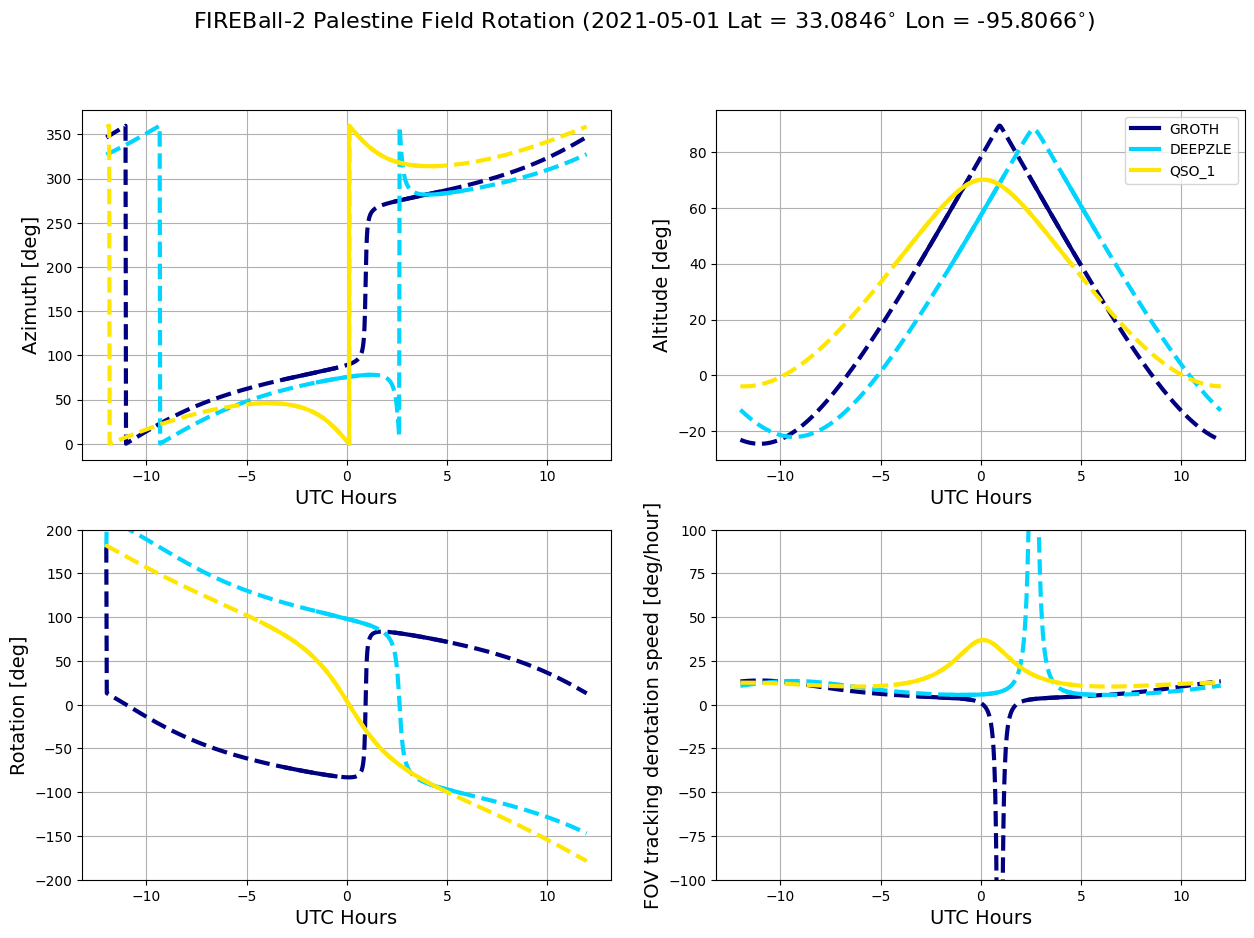

In [7]:
''' Plot all values'''

fig, ax = plt.subplots(2,2,figsize = (15,10))
fig.suptitle('FIREBall-2 Palestine Field Rotation (' 
             + date + ' Lat = ' + str(field.latlon[name][0]) + r'$\rm^{\circ}$ '
             + 'Lon = ' + str(field.latlon[name][1]) + r'$\rm^{\circ}$)', fontsize = 16)

jet = cm = plt.get_cmap('jet') 
cNorm  = colors.Normalize(vmin=0, vmax=num)
scalarMap = cmx.ScalarMappable(norm=cNorm, cmap=jet)



label = ['GROTH', 'DEEPZLE', 'QSO_1']
skip = np.arange(0, az.shape[1], 100)
for i, l in zip(range(num), label):
    
        colorVal = scalarMap.to_rgba(i)
        colorText = (
            'color: (%4.2f,%4.2f,%4.2f)'%(colorVal[0],colorVal[1],colorVal[2])
            )

        ax[0,0].plot(hour[::100], az[num-1-i,skip], c = colorVal, ls = '--', lw = 3)
        ax[0,0].plot(hour, az_new[num-1-i], c = colorVal, lw = 3, label = l)
        ax[0,1].plot(hour[::100], alt[num-1-i,skip], c=colorVal, ls = '--', lw = 3)
        ax[0,1].plot(hour, alt_new[num-1-i],  c = colorVal, lw = 3, label = l)
        ax[1,1].plot(hour[::100], rs[num-1-i,skip], c=colorVal, ls = '--', lw = 3) 
        ax[1,1].plot(hour, rs_new[num-1-i], c = colorVal, lw = 3, label = l)
        ax[1,0].plot(hour[::100], rt[num-1-i,skip],  c = colorVal, ls = '--', lw = 3)
        ax[1,0].plot(hour, rt_new[num-1-i],  c = colorVal, lw = 3, label = l)

ax[0,0].set_xlabel('UTC Hours', fontsize = 14)
ax[0,0].set_xlabel('UTC Hours', fontsize = 14)
ax[0,1].set_xlabel('UTC Hours', fontsize = 14)
ax[0,1].set_ylabel('Altitude [deg]', fontsize = 14)
ax[0,0].set_ylabel('Azimuth [deg]', fontsize = 14)
ax[1,1].set_ylabel('FOV tracking derotation speed [deg/hour]', fontsize = 14)
ax[1,1].set_xlabel('UTC Hours', fontsize = 14)
ax[1,0].set_xlabel('UTC Hours', fontsize = 14)
ax[1,0].set_ylabel('Rotation [deg]', fontsize =14)

#ax[0,0].set_xlim((-6,6))
#ax[0,1].set_xlim((-6,6))
#ax[1,0].set_xlim((-6,6))
#ax[1,1].set_xlim((-6,6))

ax[1,0].set_ylim(-200,200)
ax[1,1].set_ylim(-100,100)

ax[0,1].legend()

ax[0,0].grid()
ax[1,1].grid()
ax[0,1].grid()
ax[1,0].grid()
plt.savefig('field_rot3.png')
plt.show()

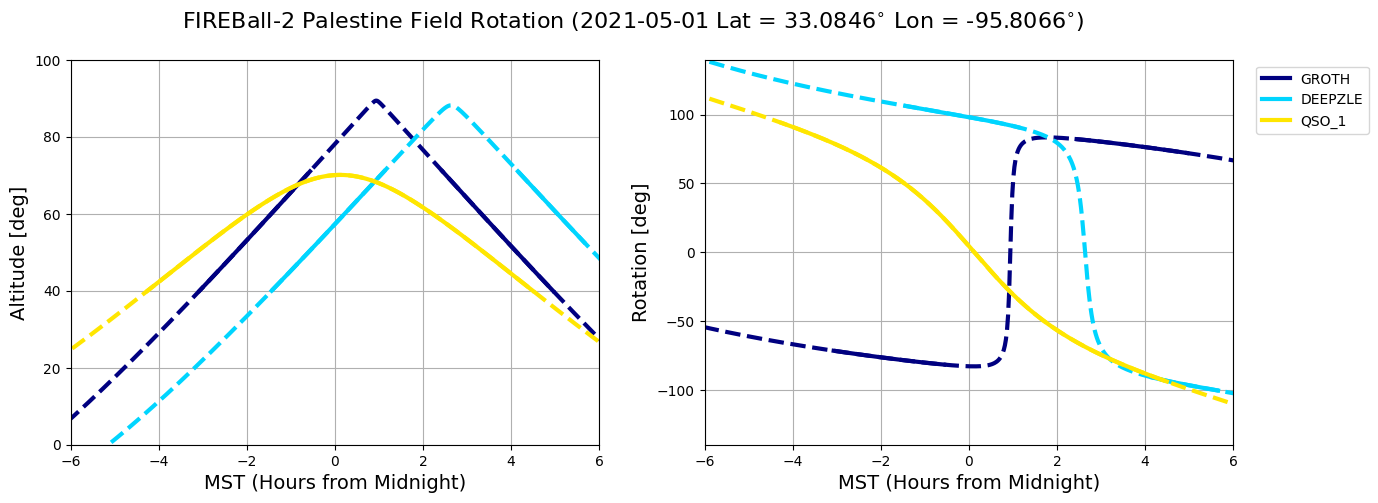

In [8]:
''' Plot just the altitude and integrated field rotation'''

fig, ax = plt.subplots(1,2,figsize = (15, 5))
fig.suptitle('FIREBall-2 Palestine Field Rotation (' 
             + date + ' Lat = ' + str(field.latlon[name][0]) + r'$\rm^{\circ}$ '
             + 'Lon = ' + str(field.latlon[name][1]) + r'$\rm^{\circ}$)', fontsize = 16)

jet = cm = plt.get_cmap('jet') 
cNorm  = colors.Normalize(vmin=0, vmax=num)
scalarMap = cmx.ScalarMappable(norm=cNorm, cmap=jet)



label = ['GROTH', 'DEEPZLE', 'QSO_1']
skip = np.arange(0, az.shape[1], 100)
for i, l in zip(range(num), label):
    
        colorVal = scalarMap.to_rgba(i)
        colorText = (
            'color: (%4.2f,%4.2f,%4.2f)'%(colorVal[0],colorVal[1],colorVal[2])
            )
        
        ax[0].plot(hour[::100], alt[num-1-i,skip], c=colorVal, ls = '--', lw = 3)
        ax[0].plot(hour, alt_new[num-1-i],  c = colorVal, lw = 3, label = l)
        ax[1].plot(hour[::100], rt[num-1-i,skip],  c = colorVal, ls = '--', lw = 3)
        ax[1].plot(hour, rt_new[num-1-i],  c = colorVal, lw = 3, label = l)

ax[0].set_xlabel('MST (Hours from Midnight)', fontsize = 14)
ax[0].set_ylabel('Altitude [deg]', fontsize = 14)

ax[1].set_xlabel('MST (Hours from Midnight)', fontsize = 14)
ax[1].set_ylabel('Rotation [deg]', fontsize =14)

ax[0].set_xlim((-6,6))
ax[1].set_xlim((-6,6))

ax[0].set_ylim(0,100)
ax[1].set_ylim(-140,140)

ax[1].legend(bbox_to_anchor = (1.27,1))

ax[0].grid()
ax[1].grid()

plt.savefig('fields.png')
plt.show()
